# **E-Commerce Business Analysis Using SQL**

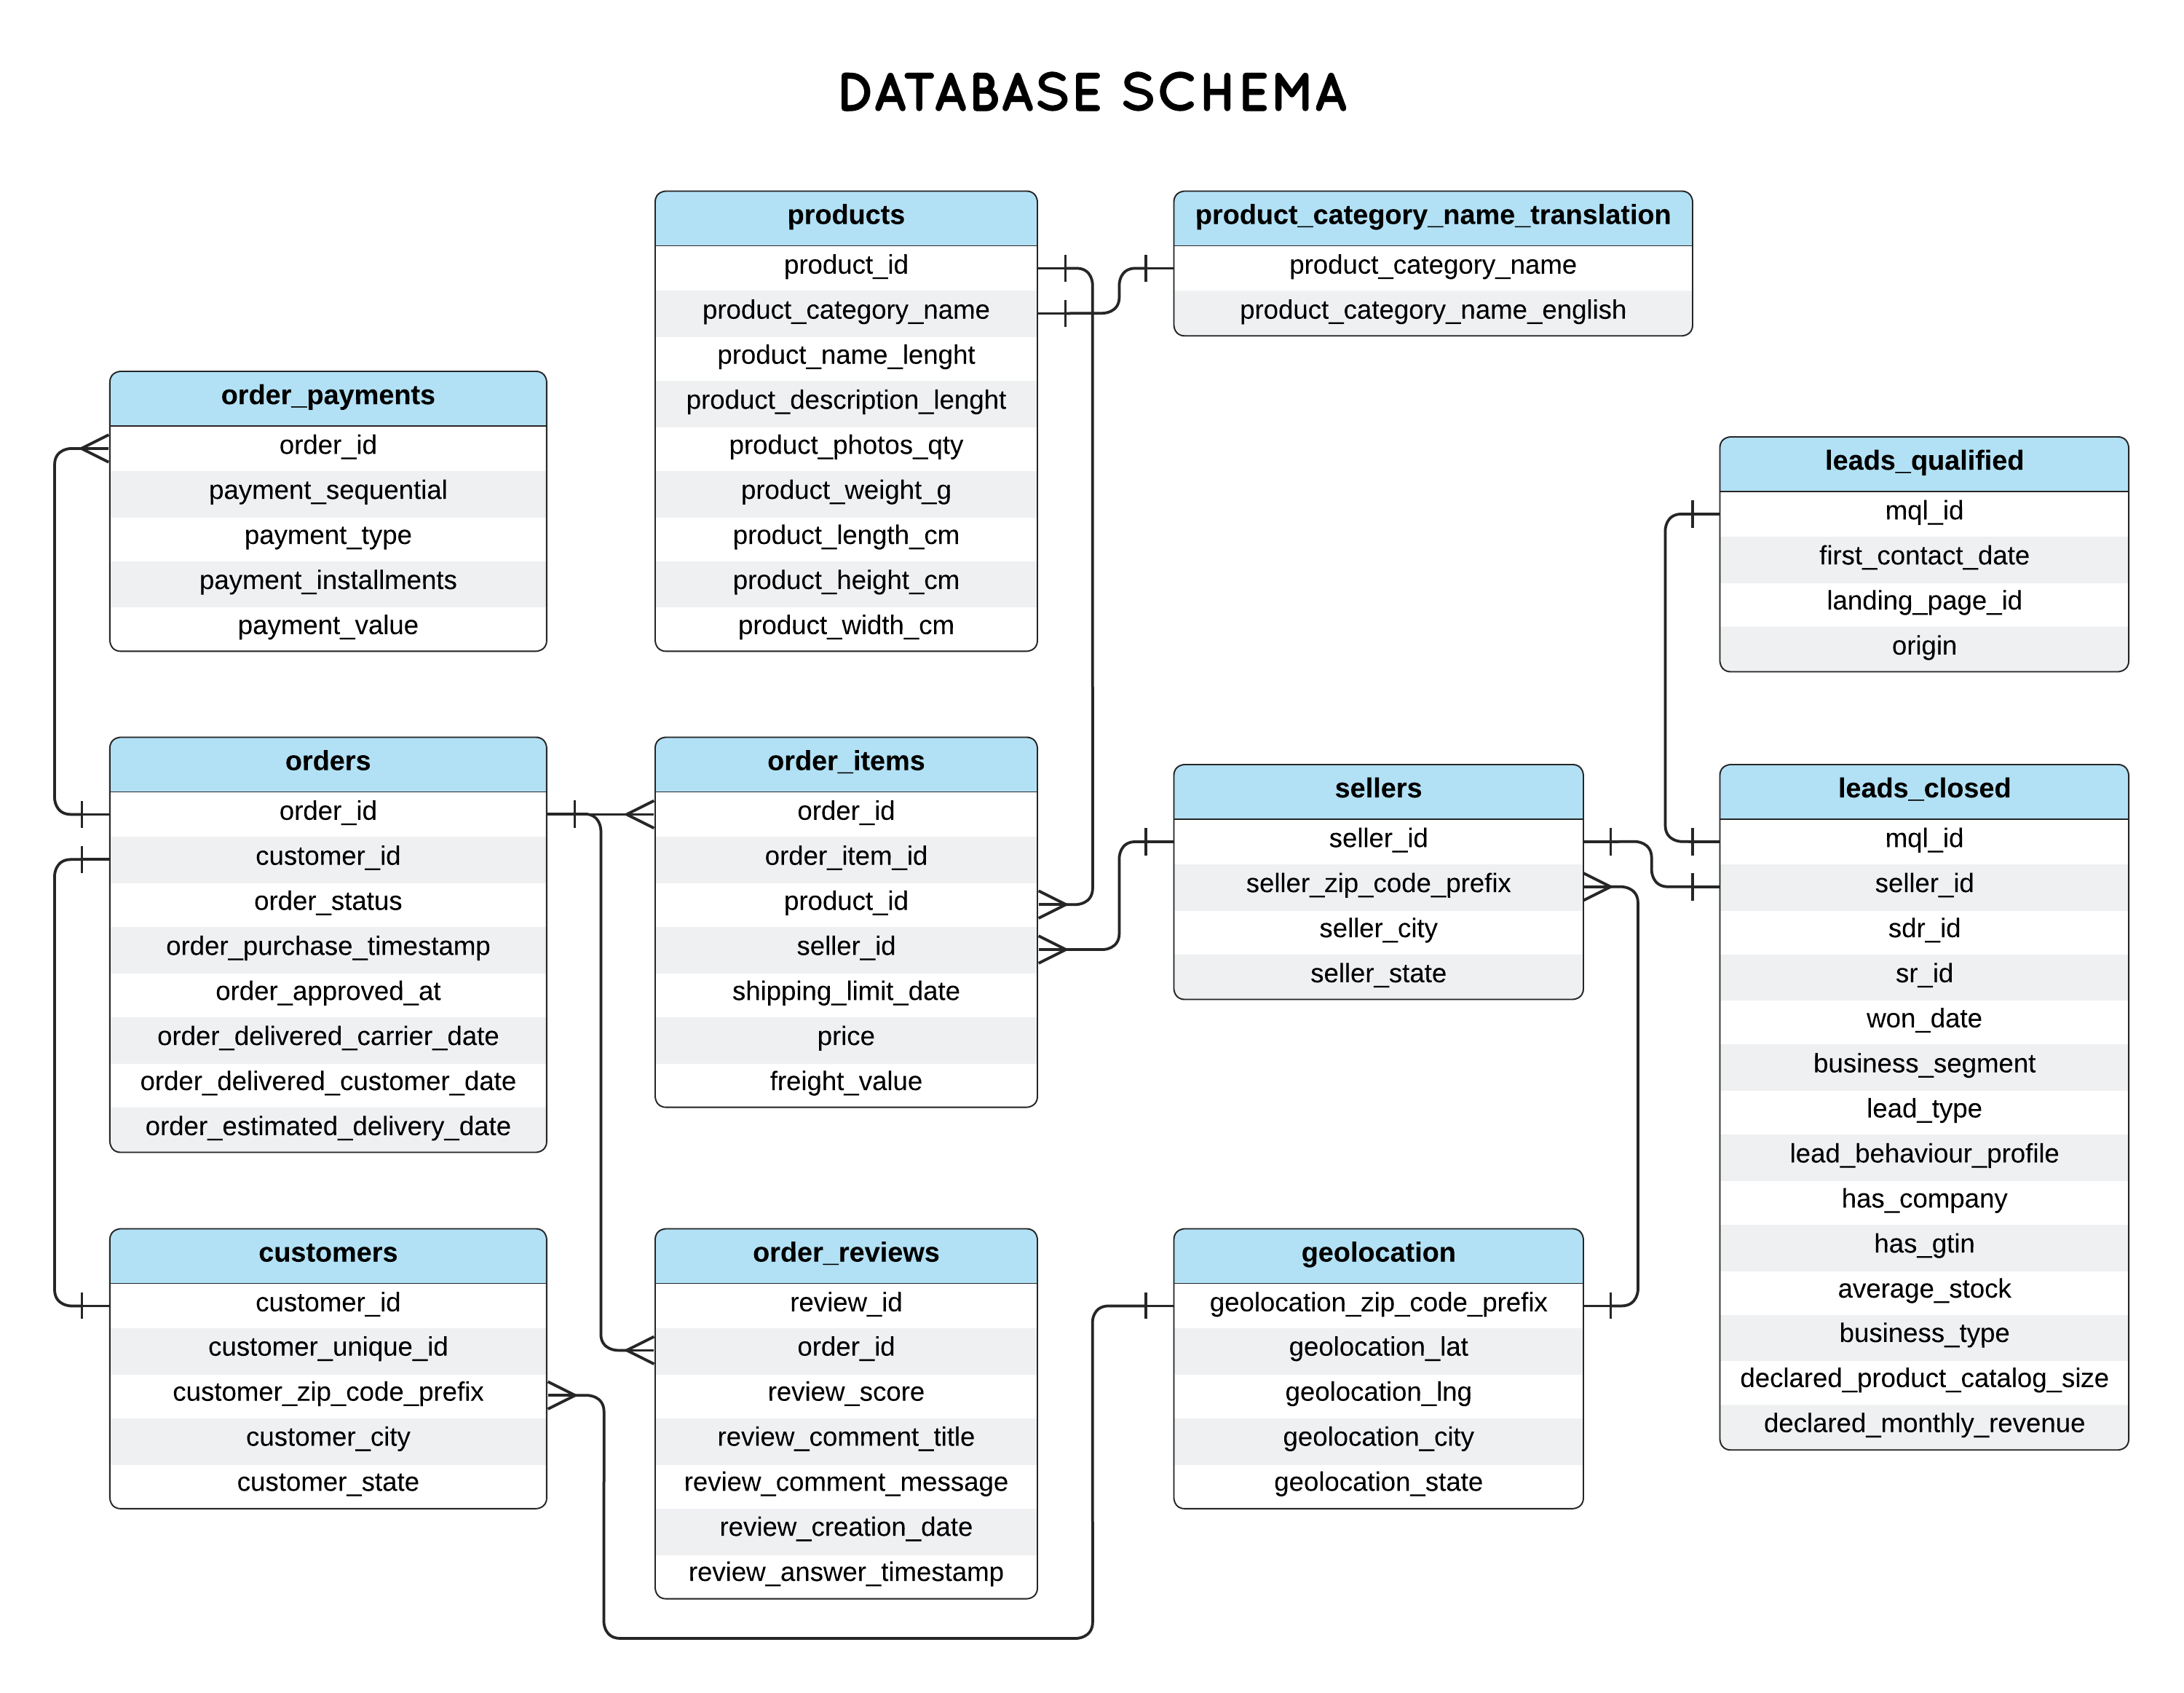
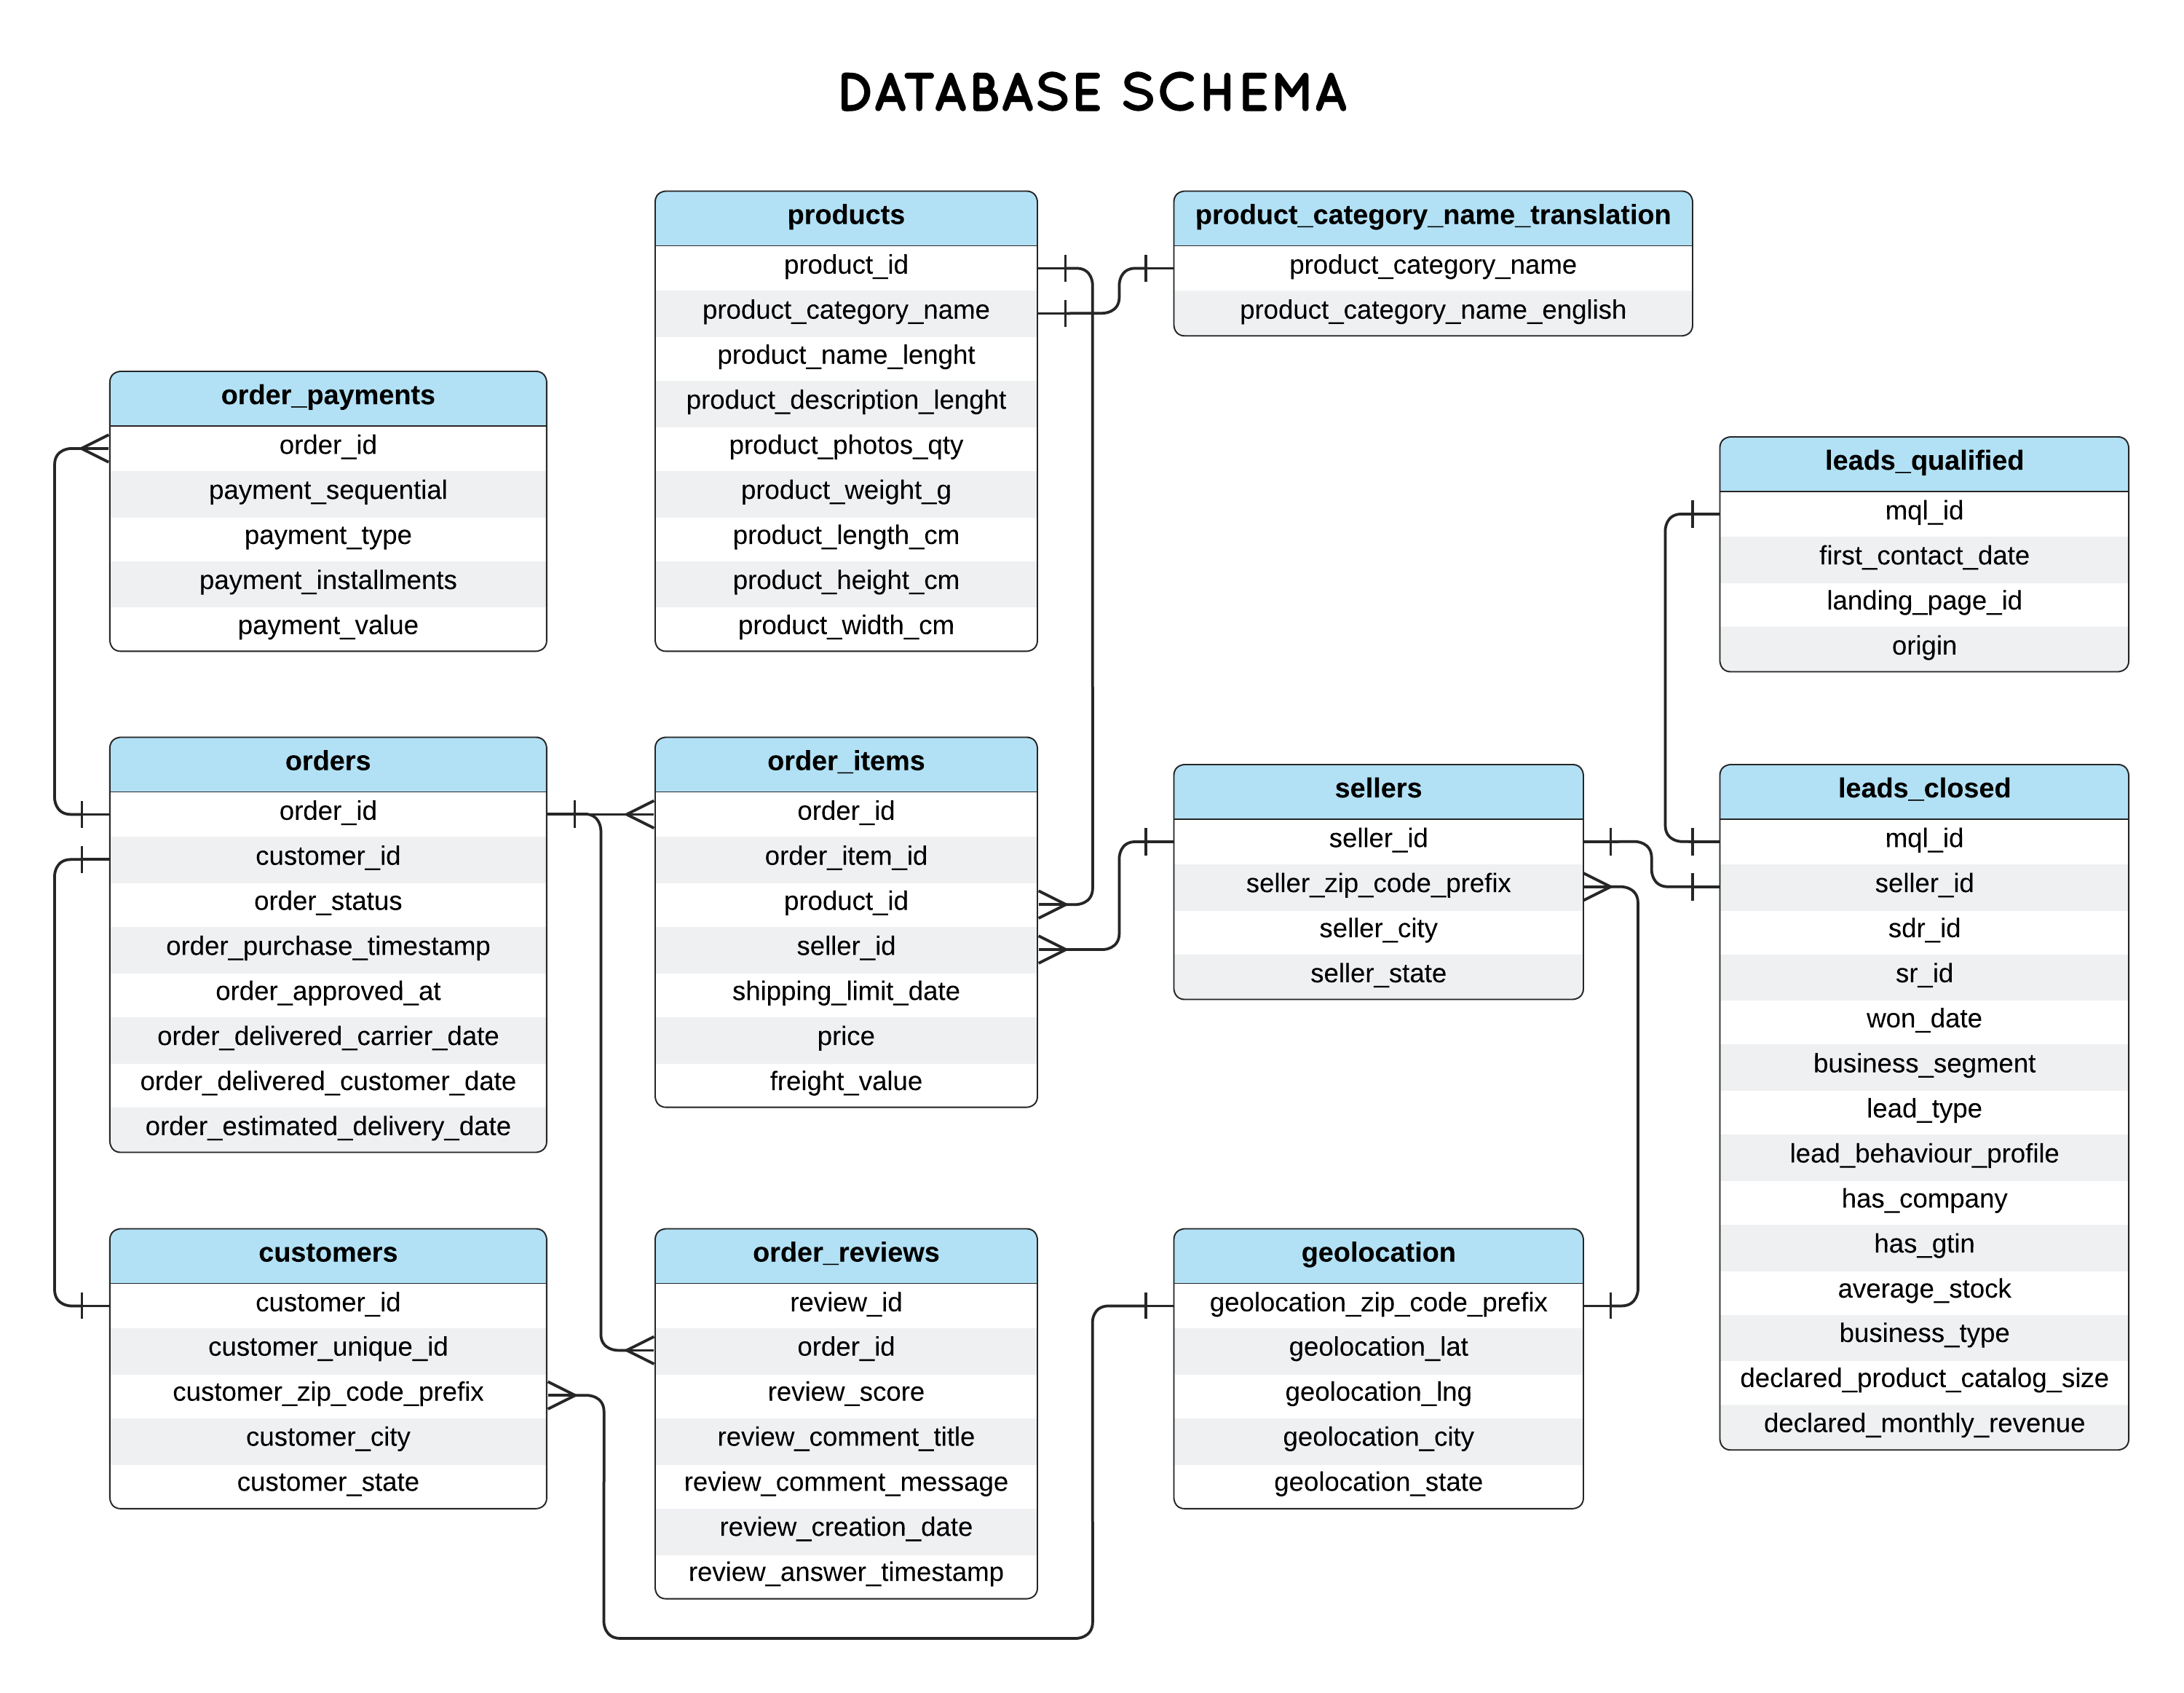

In [108]:


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/e-commerce-dataset-by-olist-as-an-sqlite-database/olist.sqlite


In [109]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [110]:
warnings.filterwarnings('ignore')

In [111]:
url='/kaggle/input/e-commerce-dataset-by-olist-as-an-sqlite-database/olist.sqlite'

In [112]:
db_connection=sqlite3.connect(url)

In [113]:
def sql_query(q):
    return pd.read_sql_query(q,db_connection)

In [114]:
q='SELECT * FROM sqlite_master'

In [115]:
sql_query(q)

,type,name,tbl_name,rootpage,sql
0,table,product_category_name_translation,product_category_name_translation,2,"CREATE TABLE ""product_category_name_translatio..."
1,table,sellers,sellers,3,"CREATE TABLE ""sellers"" (\n""seller_id"" TEXT,\n ..."
2,table,customers,customers,48,"CREATE TABLE ""customers"" (\n""customer_id"" TEXT..."
3,table,geolocation,geolocation,2282,"CREATE TABLE ""geolocation"" (\n""geolocation_zip..."
4,table,order_items,order_items,12881,"CREATE TABLE ""order_items"" (\n""order_id"" TEXT,..."
5,table,order_payments,order_payments,16916,"CREATE TABLE ""order_payments"" (\n""order_id"" TE..."
6,table,order_reviews,order_reviews,18508,"CREATE TABLE ""order_reviews"" (\n""review_id"" TE..."
7,table,orders,orders,22174,"CREATE TABLE ""orders"" (\n""order_id"" TEXT,\n ""..."
8,table,products,products,26706,"CREATE TABLE ""products"" (\n""product_id"" TEXT,\..."
9,table,leads_qualified,leads_qualified,27283,"CREATE TABLE ""leads_qualified"" (\n""mql_id"" TEX..."


# 💰 Sales & Revenue

###   What is the total revenue and how does it change over time?

In [116]:
q='''SELECT * FROM order_payments'''

In [117]:
sql_query(q)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54


In [118]:
q='''SELECT * FROM orders'''
sql_query(q)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [119]:
q='''SELECT ROUND(SUM(odpym.payment_value)) Total_Revenue,
     STRFTIME('%Y',ord.order_purchase_timestamp) AS Year,
     STRFTIME('%m',ord.order_purchase_timestamp) AS Month
     FROM order_payments odpym
     INNER join orders ord
     on
     odpym.order_id =ord.order_id
     GROUP BY Year,Month
     ORDER BY Year asc
     '''

In [120]:
df1=sql_query(q)
df1

,Total_Revenue,Year,Month
0,252.0,2016,09
1,59090.0,2016,10
2,20.0,2016,12
3,138488.0,2017,01
4,291908.0,2017,02
5,449864.0,2017,03
6,417788.0,2017,04
7,592919.0,2017,05
8,511276.0,2017,06
9,592383.0,2017,07


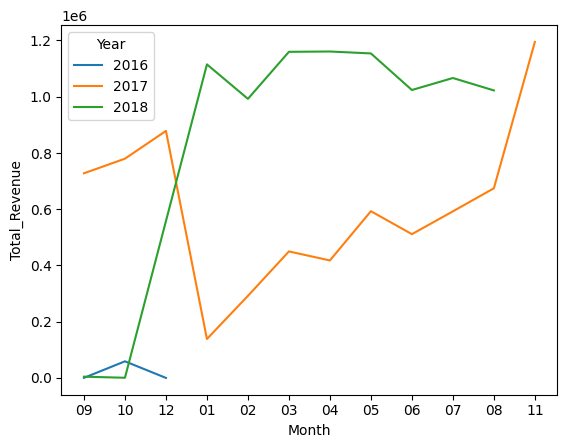

In [121]:
sns.lineplot(data=df1, x="Month", y="Total_Revenue", hue="Year")
plt.show()

## Insight:
Revenue increased rapidly from 2016 to 2017, showing strong business growth.
Sales remained consistently high throughout 2018, indicating a stable and
mature market presence. The unusually low values in late 2018 likely reflect
incomplete data rather than a true decline in sales.

# 🛍️ Products

###   Which product categories generate the most sales

In [122]:
q='''SELECT * FROM products'''
sql_query(q)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [123]:
q='''SELECT pcnt.product_category_name_english AS product_category,
SUM(oditem.price+oditem.freight_value) as Total_product_category_revenue
FROM product_category_name_translation pcnt
INNER JOIN  products pro
on pcnt.product_category_name =pro.product_category_name
INNER JOIN  order_items oditem
on
pro.product_id = oditem.product_id
GROUP BY product_category
ORDER BY Total_product_category_revenue desc
limit 15
'''


In [124]:
df2=sql_query(q)
df2

,product_category,Total_product_category_revenue
0,health_beauty,1441248.07
1,watches_gifts,1305541.61
2,bed_bath_table,1241681.72
3,sports_leisure,1156656.48
4,computers_accessories,1059272.40
5,furniture_decor,902511.79
6,housewares,778397.77
7,cool_stuff,719329.95
8,auto,685384.32
9,garden_tools,584219.21


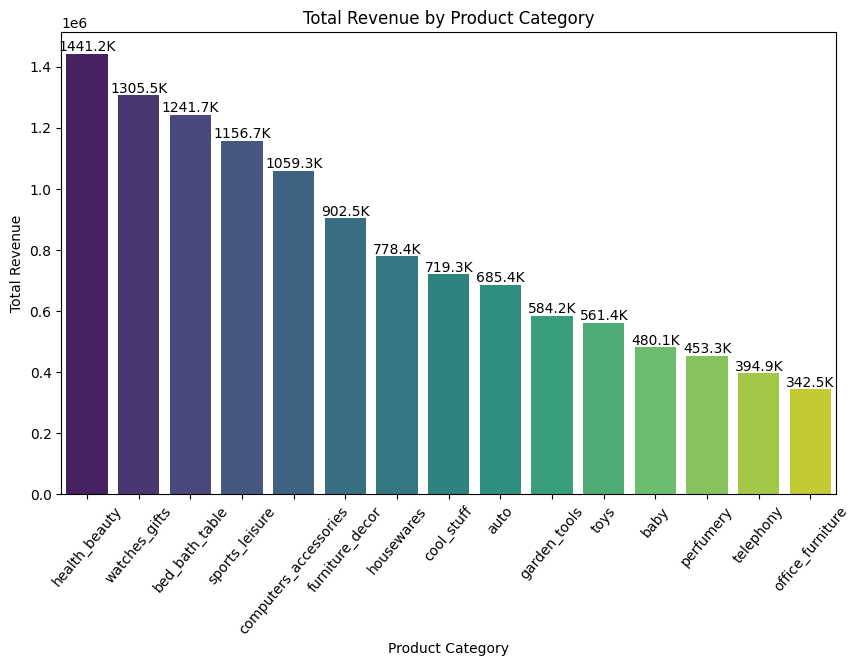

In [180]:
plt.figure(figsize=(10,6))
ax = sns.barplot(x=df2["product_category"],
                 y=df2["Total_product_category_revenue"],palette="viridis")
plt.xticks(rotation=50)
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.title("Total Revenue by Product Category")

# Add bar labels in K format
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height/1000:.1f}K',       # Rounded and in K
        (p.get_x() + p.get_width() / 2, height),
        ha='center', 
        va='bottom'
    )

plt.show()


## Insight:
The health_beauty category generates the highest revenue, totaling 1,441,248.07.
This is followed by watches_gifts with revenue of 1,305,541.61 and bed_bath_table
with 1,241,681.72.
Other strong-performing categories include sports_leisure and
computers_accessories, generating 1,156,656.48 and 1,059,272.40 respectively.
This indicates that personal care, lifestyle products, and home-related
items are the most significant contributors to overall sales.

# 👥 Customers

###   How many unique customers are there and how often do they repeat purchases?

In [126]:
q='''SELECT * FROM customers'''
sql_query(q)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS


count repeat customer

In [127]:
q='''SELECT
    COUNT(DISTINCT customer_unique_id) AS total_customers,

    SUM(
        CASE 
            WHEN order_count > 1 THEN 1 
            ELSE 0 
        END
    ) AS repeat_customers,

    ROUND(
        100.0 * SUM(CASE WHEN order_count > 1 THEN 1 ELSE 0 END)
        / COUNT(DISTINCT customer_unique_id),
        2
    ) AS repeat_rate_percentage

FROM (
    SELECT 
        cus.customer_unique_id,
        COUNT(ord.order_id) AS order_count
    FROM customers cus
    INNER JOIN orders ord
        ON cus.customer_id = ord.customer_id
    GROUP BY cus.customer_unique_id
) t'''

In [128]:
df3=sql_query(q)
df3

,total_customers,repeat_customers,repeat_rate_percentage
0,96096,2997,3.12


## Insight:
This insight shows that No of Total customers are 96,096.No of repeated customers are 2997 and customer repeat customer persentage is 3.12% persent.

# 🚚Delivery

###  What is the average delivery time and how many orders are delayed?

In [129]:
q3='''SELECT * FROM orders'''

In [130]:
sql_query(q3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [131]:
q ='''SELECT Round(Avg(JULIANDAY(order_delivered_customer_date)-JULIANDAY(order_purchase_timestamp)),2) as Average_Delivery_Time,
      COUNT(CASE WHEN order_delivered_customer_date > order_estimated_delivery_date THEN "delay" END) AS Delay_Orders
      FROM orders
'''

In [132]:
df4=sql_query(q)
df4

,Average_Delivery_Time,Delay_Orders
0,12.56,7827


## Insight:
The average delivery time is approximately 12.56 days from purchase to customer delivery.
Additionally, 7,827 orders were delivered later than the estimated delivery date,
indicating delays in the logistics process for a portion of orders.


# 💳 Payments
### Which payment types are most used and what is the average order value?


In [133]:
q3='''SELECT * FROM order_payments'''
sql_query(q3)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54


In [134]:
q='''SELECT payment_type AS payment_mode_used,
COUNT(*) AS usage_count,
ROUND(Avg(payment_value),2) as average_payment_value
FROM order_payments
GROUP BY payment_mode_used
HAVING average_payment_value > 1
'''

In [135]:
df5=sql_query(q)
df5

,payment_mode_used,usage_count,average_payment_value
0,boleto,19784,145.03
1,credit_card,76795,163.32
2,debit_card,1529,142.57
3,voucher,5775,65.70


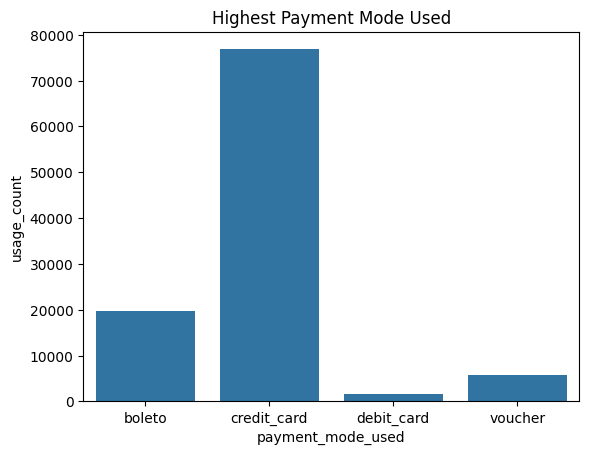

In [136]:
sns.barplot(x=df5['payment_mode_used'],y=df5['usage_count'])
plt.title("Highest Payment Mode Used")
plt.show()

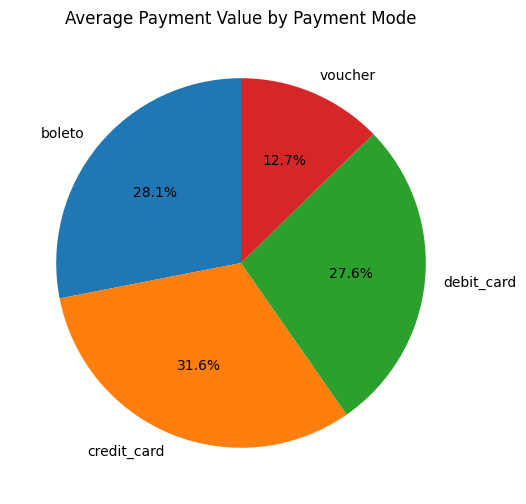

In [137]:
df=pd.DataFrame({
    "payment_mode_used":df5['payment_mode_used'],
    "average_payment_value":df5['average_payment_value']
})
plt.figure(figsize=(6,6))

plt.pie(
    df["average_payment_value"],
    labels=df["payment_mode_used"],
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Average Payment Value by Payment Mode")

plt.show()


## Insight:
This analysis shows that higest payment mode used in credit card to genrate a revenue.customer spent a average payment value is 163 to buy a things.



# 🏪 Sellers

### Which sellers perform best in terms of revenue and number of orders

In [138]:
q='''SELECT ordpay.payment_value,ord.customer_id
  FROM orders ord
  INNER join order_payments ordpay
  ON
  ord.order_id = ordpay.order_id
  GROUP BY ord.customer_id
  ORDER BY payment_value desc
'''
sql_query(q)

,payment_value,customer_id
0,13664.08,1617b1357756262bfa56ab541c47bc16
1,7274.88,ec5b2ba62e574342386871631fafd3fc
2,6929.31,c6e2731c5b391845f6800c97401a43a9
3,6922.21,f48d464a0baaea338cb25f816991ab1f
4,6726.66,3fd6777bbce08a352fddd04e4a7cc8f6
...,...,...
99435,0.00,8eab8f9b3c744b76b65f7a2c0c8f2d6c
99436,0.00,843b211abe7b0264dd4a69eafc5bdf43
99437,0.00,648121b599d98c420ef93f6135f8c80c
99438,0.00,3532ba38a3fd242259a514ac2b6ae6b6


In [139]:
q='''SELECT * FROM order_items'''
sql_query(q)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


In [140]:
q='''With top_seller as(SELECT orditm.seller_id AS seller_id,count(*) AS no_of_orders,
     SUM(orditm.price+orditm.freight_value) AS Total_revenue ,
     RANK() OVER(ORDER BY SUM(orditm.price+orditm.freight_value) Desc) AS Ranking
     FROM order_items orditm
     GROUP BY seller_id)
     SELECT seller_id, no_of_orders,Total_revenue FROM top_seller
     where Ranking <11
     '''


In [141]:
df6=sql_query(q)
df6

,seller_id,no_of_orders,Total_revenue
0,4869f7a5dfa277a7dca6462dcf3b52b2,1156,249640.70
1,7c67e1448b00f6e969d365cea6b010ab,1364,239536.44
2,53243585a1d6dc2643021fd1853d8905,410,235856.68
3,4a3ca9315b744ce9f8e9374361493884,1987,235539.96
4,fa1c13f2614d7b5c4749cbc52fecda94,586,204084.73
5,da8622b14eb17ae2831f4ac5b9dab84a,1551,185192.32
6,7e93a43ef30c4f03f38b393420bc753a,340,182754.05
7,1025f0e2d44d7041d6cf58b6550e0bfa,1428,172860.69
8,7a67c85e85bb2ce8582c35f2203ad736,1171,162648.38
9,955fee9216a65b617aa5c0531780ce60,1499,160602.68


In [142]:
df = pd.DataFrame({
    "seller_id": [
        "4869f7a5dfa277a7dca6462dcf3b52b2",
        "7c67e1448b00f6e969d365cea6b010ab",
        "53243585a1d6dc2643021fd1853d8905",
        "4a3ca9315b744ce9f8e9374361493884",
        "fa1c13f2614d7b5c4749cbc52fecda94",
        "da8622b14eb17ae2831f4ac5b9dab84a",
        "7e93a43ef30c4f03f38b393420bc753a",
        "1025f0e2d44d7041d6cf58b6550e0bfa",
        "7a67c85e85bb2ce8582c35f2203ad736",
        "955fee9216a65b617aa5c0531780ce60"
    ],
    "no_of_orders": [1156,1364,410,1987,586,1551,340,1428,1171,1499],
    "Total_revenue": [249640.70,239536.44,235856.68,235539.96,204084.73,
                      185192.32,182754.05,172860.69,162648.38,160602.68]
})

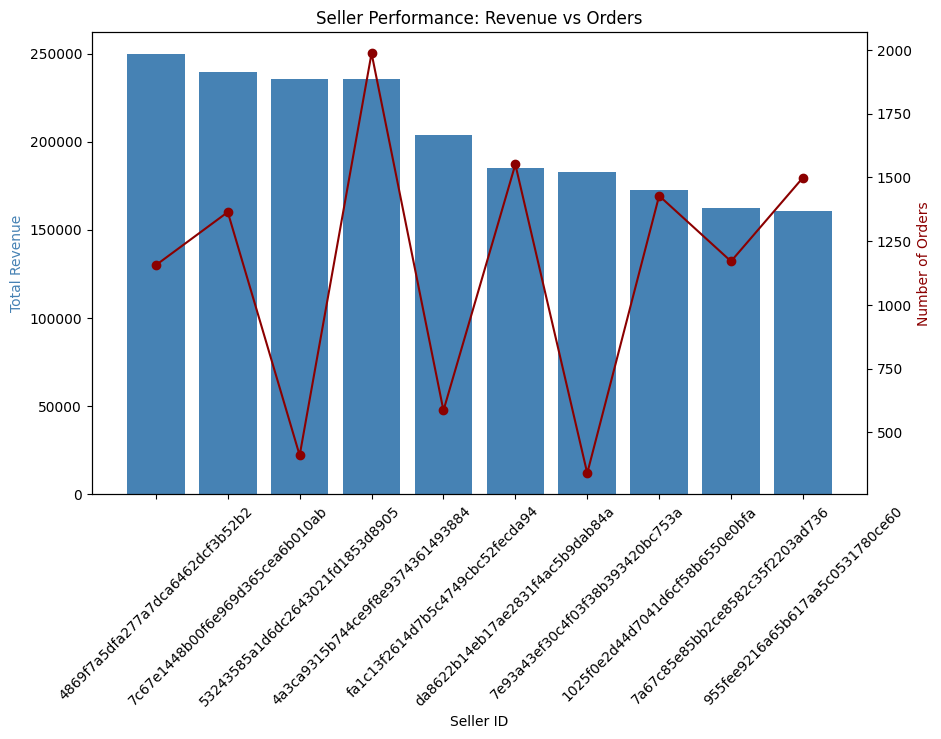

In [143]:

df = df.sort_values(by="Total_revenue", ascending=False)

fig, ax1 = plt.subplots(figsize=(10,6))


ax1.bar(df["seller_id"], df["Total_revenue"], color='steelblue')
ax1.set_ylabel("Total Revenue", color='steelblue')
ax1.set_xlabel("Seller ID")
plt.xticks(rotation=45)


ax2 = ax1.twinx()
ax2.plot(df["seller_id"], df["no_of_orders"], color='darkred', marker='o')
ax2.set_ylabel("Number of Orders", color='darkred')

plt.title("Seller Performance: Revenue vs Orders")
plt.show()

# Insight:
The seller with ID 4869f7a5dfa277a7dca6462dcf3b52b2 generated the highest revenue
(249,640.70) from 1,156 orders. The second highest revenue was generated by
seller 7c67e1448b00f6e969d365cea6b010ab with 239,536.44 from 1,364 orders.

Interestingly, seller 4a3ca9315b744ce9f8e9374361493884 processed the largest
number of orders (1,987) but ranked fourth in revenue, suggesting that this
seller may be selling lower-priced products compared to others.

Overall, the results show that revenue does not always increase with the
number of orders, indicating differences in product pricing among sellers.

# 🌍 Location

###  Which cities/states generate the most orders and revenue?

In [144]:
q='''SELECT * FROM customers'''
sql_query(q)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS


In [145]:
q='''With cities as(SELECT c.customer_city as Cities,ROUND(SUM(op.payment_value)) AS Total_revenue,
     COUNT(Distinct o.order_id) AS  No_of_orders,
     RANK()OVER(ORDER BY SUM(op.payment_value) desc) As Ranks
     FROM customers c
     
     INNER JOIN orders o
     ON
     c.customer_id = o.customer_id
     INNER JOIN order_payments op
     ON
     o.order_id=op.order_id
     GROUP BY customer_city
     )
     SELECT Cities,No_of_orders,Total_revenue FROM cities
     WHERE Ranks < 11'''


In [146]:
df7=sql_query(q)
df7

,Cities,No_of_orders,Total_revenue
0,sao paulo,15540,2203373.0
1,rio de janeiro,6882,1161927.0
2,belo horizonte,2773,421765.0
3,brasilia,2131,354217.0
4,curitiba,1521,247392.0
5,porto alegre,1379,224731.0
6,salvador,1245,218071.0
7,campinas,1444,216248.0
8,guarulhos,1189,165122.0
9,niteroi,849,139997.0


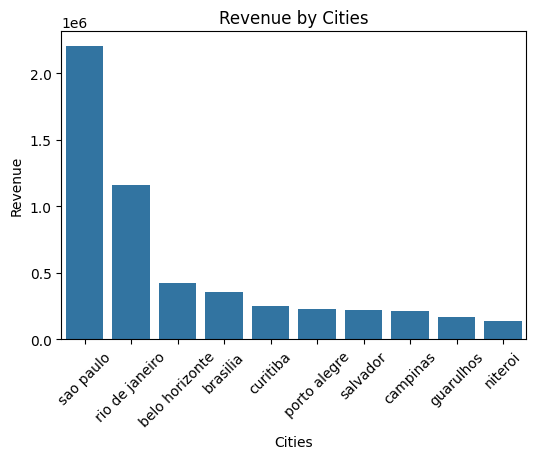

In [147]:
plt.figure(figsize=(6,4))
sns.barplot(x="Cities", y="Total_revenue", data=df7)
plt.xticks(rotation=45)
plt.xlabel("Cities")
plt.ylabel("Revenue")
plt.title("Revenue by Cities")
plt.show()

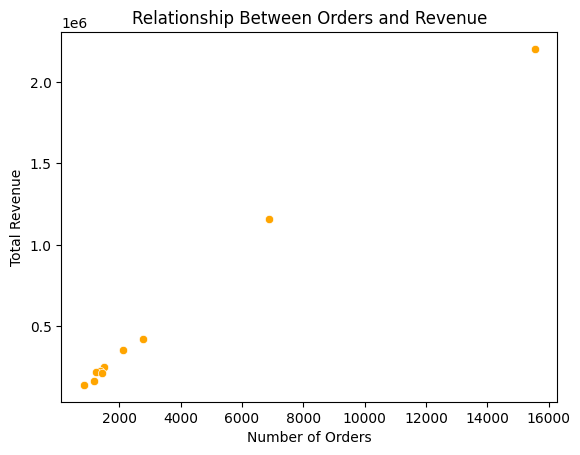

In [148]:
sns.scatterplot(data=df7, x="No_of_orders", y="Total_revenue",color="orange")

plt.title("Relationship Between Orders and Revenue")
plt.xlabel("Number of Orders")
plt.ylabel("Total Revenue")

plt.show()

# Insight:
São Paulo generates the highest number of orders (15,540) and the largest revenue (2.20M), making it the top-performing city. It is followed by Rio de Janeiro with 6,882 orders and 1.16M revenue. Other cities such as Belo Horizonte and Brasilia also contribute significantly but at a much lower level. Overall, a large share of orders and revenue is concentrated in a few major cities.


# 📦 Orders
### What is the average number of items per order?


In [149]:
q='''SELECT * FROM order_items'''
sql_query(q)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


In [150]:
q='''SELECT COUNT(od.order_id) AS total_item,
     COUNT(distinct od.order_id) AS total_order,
     (COUNT(od.order_id)/COUNT(distinct od.order_id)) AS avg_number_of_item_per_order
     FROM order_items od
'''

In [151]:
df8=sql_query(q)
df8

,total_item,total_order,avg_number_of_item_per_order
0,112650,98666,1


# Insight:
On average, customers purchase 1.14 items per order, indicating that most orders contain only one item, with few multi-item purchases. This suggests an opportunity to increase order value through bundling, cross-selling, or promotional offers.

# 📈 Leads & Conversion


### What is the conversion rate from leads to closed deals andHow many qualified leads convert to closed deals?


In [152]:
q='''SELECT * FROM leads_qualified'''
sql_query(q)

,mql_id,first_contact_date,landing_page_id,origin
0,dac32acd4db4c29c230538b72f8dd87d,2018-02-01,88740e65d5d6b056e0cda098e1ea6313,social
1,8c18d1de7f67e60dbd64e3c07d7e9d5d,2017-10-20,007f9098284a86ee80ddeb25d53e0af8,paid_search
2,b4bc852d233dfefc5131f593b538befa,2018-03-22,a7982125ff7aa3b2054c6e44f9d28522,organic_search
3,6be030b81c75970747525b843c1ef4f8,2018-01-22,d45d558f0daeecf3cccdffe3c59684aa,email
4,5420aad7fec3549a85876ba1c529bd84,2018-02-21,b48ec5f3b04e9068441002a19df93c6c,organic_search
...,...,...,...,...
7995,feaba3ffcd2ff97501696c7f9a42f41c,2018-05-22,e42a14209c69c3e9cc6b042620465f12,paid_search
7996,a79cb53cd009ab92e0143b92baa2407b,2018-03-27,c494978688ccf66ad9fad3d6a3338c22,paid_search
7997,68f049a23ab109c6a0f6989bb9a02994,2017-08-27,b48ec5f3b04e9068441002a19df93c6c,organic_search
7998,4f8c96e2509b984329044c6682c88ee9,2017-10-06,a56671a54260a44923d32c2f08fad39c,organic_search


In [153]:
q='''SELECT * FROM leads_closed'''
sql_query(q)

,mql_id,seller_id,sdr_id,sr_id,won_date,business_segment,lead_type,lead_behaviour_profile,has_company,has_gtin,average_stock,business_type,declared_product_catalog_size,declared_monthly_revenue
0,5420aad7fec3549a85876ba1c529bd84,2c43fb513632d29b3b58df74816f1b06,a8387c01a09e99ce014107505b92388c,4ef15afb4b2723d8f3d81e51ec7afefe,2018-02-26 19:58:54,pet,online_medium,cat,NaN,NaN,None,reseller,NaN,0.0
1,a555fb36b9368110ede0f043dfc3b9a0,bbb7d7893a450660432ea6652310ebb7,09285259593c61296eef10c734121d5b,d3d1e91a157ea7f90548eef82f1955e3,2018-05-08 20:17:59,car_accessories,industry,eagle,NaN,NaN,None,reseller,NaN,0.0
2,327174d3648a2d047e8940d7d15204ca,612170e34b97004b3ba37eae81836b4c,b90f87164b5f8c2cfa5c8572834dbe3f,6565aa9ce3178a5caf6171827af3a9ba,2018-06-05 17:27:23,home_appliances,online_big,cat,NaN,NaN,None,reseller,NaN,0.0
3,f5fee8f7da74f4887f5bcae2bafb6dd6,21e1781e36faf92725dde4730a88ca0f,56bf83c4bb35763a51c2baab501b4c67,d3d1e91a157ea7f90548eef82f1955e3,2018-01-17 13:51:03,food_drink,online_small,None,NaN,NaN,None,reseller,NaN,0.0
4,ffe640179b554e295c167a2f6be528e0,ed8cb7b190ceb6067227478e48cf8dde,4b339f9567d060bcea4f5136b9f5949e,d3d1e91a157ea7f90548eef82f1955e3,2018-07-03 20:17:45,home_appliances,industry,wolf,NaN,NaN,None,manufacturer,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
837,df9a2abe2ad3f2d8758b675ac8331ecf,bfcc27719640628da877db48b672b169,45749fb708130f78d0db07d8d80f030b,a8387c01a09e99ce014107505b92388c,2018-08-01 20:22:31,home_decor,offline,cat,NaN,NaN,None,reseller,NaN,0.0
838,8723201570415eb23b4f095d8c20a27c,4a82eab98441aeb64566e2776c1fb2b6,370c9f455f93a9a96cbe9bea48e70033,4b339f9567d060bcea4f5136b9f5949e,2018-09-27 18:58:41,construction_tools_house_garden,online_big,wolf,NaN,NaN,None,reseller,132.0,200000.0
839,2e57665b8faf05c967a801eb5aedfa0a,55031883943971ca22db6894574cfe2c,370c9f455f93a9a96cbe9bea48e70033,a8387c01a09e99ce014107505b92388c,2018-06-06 20:15:26,computers,online_medium,wolf,NaN,NaN,None,reseller,NaN,0.0
840,40955be51cc85c5a5a6cdd12b19e9f10,c0e933c238e41f0cd459d6025ee9b364,068066e24f0c643eb1d089c7dd20cd73,d3d1e91a157ea7f90548eef82f1955e3,2018-03-06 15:52:23,pet,online_beginner,cat,NaN,NaN,None,reseller,NaN,0.0


In [154]:
q9='''
WITH leads AS(select count(DISTINCT lc.mql_id) AS closed_deal_leads, 
     COUNT(DISTINCT ld.mql_id) AS Total_qualified_leads
     FROM leads_qualified ld
     LEFT JOIN leads_closed lc
     ON
     ld.mql_id = lc.mql_id)
SELECT Total_qualified_leads,closed_deal_leads,
(closed_deal_leads* 1.0/Total_qualified_leads)*100 AS conversion_rate
        FROM leads  
'''

In [155]:
df9=sql_query(q9)
df9

,Total_qualified_leads,closed_deal_leads,conversion_rate
0,8000,842,10.525


# Insight:
Out of 8000 qualified leads, 842 leads were successfully converted into closed deals, resulting in a conversion rate of approximately 10.53%. This means that roughly 1 out of every 10 qualified leads becomes a paying customer. This metric helps evaluate the effectiveness of the sales process and lead quality.

# Conclusion:
